# Bank Fraud Detection using Machine Learning

## Objective
Build a machine learning system that detects fraudulents transactions.

## Technologies
- Python
- Pandas
- Numpy
- Scikit-learn
- XGBoost
- SHAP
- Streamlit
- FastAPI

## Project Goal
Detect fraudulent transactions While minimizing false positives.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
import shap

import shap

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
df = pd.read_csv("/content/creditcard.csv")

In [15]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283140,171397.0,-0.254333,0.494893,0.783833,-0.894191,0.553898,-1.230924,1.161303,-0.393764,-0.193330,-0.294848,1.285844,0.897139,-0.313439,0.119693,-1.430896,0.070111,-0.769782,-0.514484,-0.525843,-0.170387,-0.151866,-0.360438,0.092942,0.536912,-0.600539,-0.059604,-0.318109,-0.144452,16.00,0.0
283141,171398.0,-0.943864,0.836655,0.292689,-0.723866,0.873360,0.545275,0.710274,0.602397,-0.636504,-1.214351,-0.455679,0.651790,0.303791,0.488004,0.140440,-1.128422,0.782360,-2.156077,-0.997310,-0.193194,-0.017617,-0.077826,0.056577,-1.008943,-0.290398,0.373463,-0.033192,0.033956,44.72,0.0
283142,171398.0,-2.149728,1.810804,-1.509192,-0.693237,0.415451,-0.875696,0.531266,-0.032141,1.019081,0.718613,-0.915369,-0.386748,-0.612209,-1.092653,-0.034489,0.402806,0.425526,-0.176931,-0.170894,-0.309333,-0.306518,-0.947940,0.369640,0.445435,-0.356238,0.016897,-1.064181,0.329735,10.98,0.0
283143,171399.0,-0.612184,1.263673,2.083651,2.499148,0.825444,0.786503,0.913700,-0.061163,-1.199105,0.779886,-1.913224,-0.815450,0.206096,-0.522099,-0.726729,1.398002,-1.403465,-0.022860,-1.414118,-0.089283,-0.221725,-0.591816,-0.140595,-0.739479,-0.333499,-0.374199,-0.167668,-0.084052,37.95,0.0


In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
283140,171397.0,-0.254333,0.494893,0.783833,-0.894191,0.553898,-1.230924,1.161303,-0.393764,-0.193330,-0.294848,1.285844,0.897139,-0.313439,0.119693,-1.430896,0.070111,-0.769782,-0.514484,-0.525843,-0.170387,-0.151866,-0.360438,0.092942,0.536912,-0.600539,-0.059604,-0.318109,-0.144452,16.00,0.0
283141,171398.0,-0.943864,0.836655,0.292689,-0.723866,0.873360,0.545275,0.710274,0.602397,-0.636504,-1.214351,-0.455679,0.651790,0.303791,0.488004,0.140440,-1.128422,0.782360,-2.156077,-0.997310,-0.193194,-0.017617,-0.077826,0.056577,-1.008943,-0.290398,0.373463,-0.033192,0.033956,44.72,0.0
283142,171398.0,-2.149728,1.810804,-1.509192,-0.693237,0.415451,-0.875696,0.531266,-0.032141,1.019081,0.718613,-0.915369,-0.386748,-0.612209,-1.092653,-0.034489,0.402806,0.425526,-0.176931,-0.170894,-0.309333,-0.306518,-0.947940,0.369640,0.445435,-0.356238,0.016897,-1.064181,0.329735,10.98,0.0
283143,171399.0,-0.612184,1.263673,2.083651,2.499148,0.825444,0.786503,0.913700,-0.061163,-1.199105,0.779886,-1.913224,-0.815450,0.206096,-0.522099,-0.726729,1.398002,-1.403465,-0.022860,-1.414118,-0.089283,-0.221725,-0.591816,-0.140595,-0.739479,-0.333499,-0.374199,-0.167668,-0.084052,37.95,0.0
283144,171400.0,1.209070,-2.338353,-4.422113,-1.100578,2.146988,2.885949,0.657054,0.267981,-1.383349,0.808358,-0.225478,-0.154596,-0.003269,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(283145, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283145 entries, 0 to 283144
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283145 non-null  float64
 1   V1      283145 non-null  float64
 2   V2      283145 non-null  float64
 3   V3      283145 non-null  float64
 4   V4      283145 non-null  float64
 5   V5      283145 non-null  float64
 6   V6      283145 non-null  float64
 7   V7      283145 non-null  float64
 8   V8      283145 non-null  float64
 9   V9      283145 non-null  float64
 10  V10     283145 non-null  float64
 11  V11     283145 non-null  float64
 12  V12     283145 non-null  float64
 13  V13     283145 non-null  float64
 14  V14     283145 non-null  float64
 15  V15     283144 non-null  float64
 16  V16     283144 non-null  float64
 17  V17     283144 non-null  float64
 18  V18     283144 non-null  float64
 19  V19     283144 non-null  float64
 20  V20     283144 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283145.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000,283144.000000
mean,94360.470738,-0.000492,-0.002182,0.004469,0.000739,-0.001600,0.000802,-0.001125,-0.000248,-0.000191,0.000187,0.002142,-0.001555,-0.000030,0.000628,0.001111,0.000117,0.000183,-0.000562,-0.000105,0.000091,-0.000076,-0.000503,-0.000212,-0.000086,0.000775,-0.000009,-0.000072,0.000023,88.456790,0.001738
std,47256.049483,1.958663,1.651813,1.515287,1.415901,1.379165,1.331407,1.235181,1.195086,1.099068,1.088100,1.020943,1.000623,0.995904,0.958950,0.915964,0.876620,0.850016,0.838437,0.814198,0.771861,0.735626,0.725335,0.625197,0.605799,0.520999,0.482381,0.403745,0.330306,249.743529,0.041649
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,-4.797473,-18.683715,-5.791881,-19.214325,-4.498945,-14.129855,-25.162799,-9.498746,-7.213527,-54.497720,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54019.000000,-0.920446,-0.599797,-0.883909,-0.848815,-0.693752,-0.767288,-0.554708,-0.208134,-0.643811,-0.534780,-0.760346,-0.407414,-0.648873,-0.424482,-0.582054,-0.468385,-0.483408,-0.498850,-0.456698,-0.211656,-0.228221,-0.541851,-0.161945,-0.354572,-0.316244,-0.327180,-0.070815,-0.052878,5.640000,0.000000
50%,84394.000000,0.018481,0.064546,0.184545,-0.018655,-0.056567,-0.272917,0.038918,0.022594,-0.052016,-0.092450,-0.029865,0.138842,-0.013895,0.050946,0.049711,0.066512,-0.065386,-0.004212,0.003694,-0.062257,-0.029544,0.006549,-0.011438,0.041129,0.018047,-0.052484,0.001421,0.011345,22.000000,0.000000
75%,138823.000000,1.314410,0.802027,1.030211,0.745603,0.609922,0.399623,0.569274,0.327221,0.597638,0.454753,0.741520,0.617871,0.662507,0.493253,0.650975,0.523768,0.399718,0.500390,0.459253,0.133405,0.185975,0.527208,0.147276,0.439107,0.351315,0.241331,0.090903,0.078218,77.500000,0.000000
max,171400.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,23.745136,12.018913,7.848392,7.126883,10.526766,8.877742,17.315112,9.253526,5.041069,5.591971,39.420904,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [14]:
df["Class"].value_counts()

,count
Class,
0.0,282652
1.0,492


In [16]:
df["Class"].value_counts(normalize=True)*100

,proportion
Class,
0.0,99.826237
1.0,0.173763


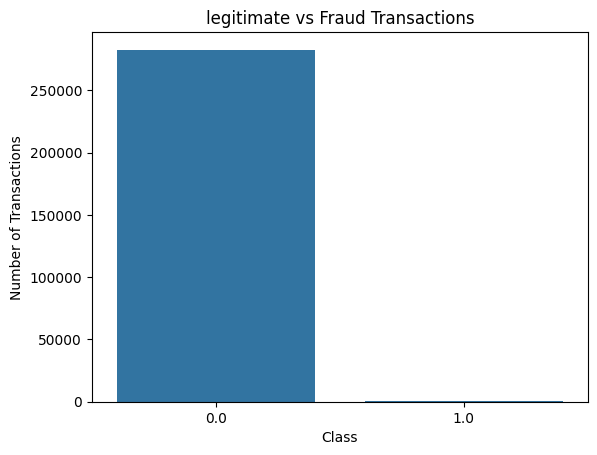

In [25]:
sns.countplot(x="Class", data=df)

plt.title("legitimate vs Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [18]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [19]:
df.isnull().sum().sum()

np.int64(16)

In [20]:
df[df.isnull().any(axis=1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
283144,171400.0,1.20907,-2.338353,-4.422113,-1.100578,2.146988,2.885949,0.657054,0.267981,-1.383349,0.808358,-0.225478,-0.154596,-0.003269,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df = df.dropna()

In [23]:
df.isnull().sum().sum()

np.int64(0)